# Benchmark: Differentiable Cloud-in-Cell (CIC) Charge Deposition

This notebook benchmarks the performance of the **differentiable Cloud-in-Cell (CIC) charge deposition** implementation in Cheetah.

It compares **Chenran Xu's original loop-based implementation** against the **current optimized tensorised implementation** across two configurations:

1. **Direct Function Benchmark**: Benchmarks the `cloud_in_cell_charge_deposition` function directly.
2. **Screen Element Benchmark**: Benchmarks image reading generation using a `Screen` element with the `'cloud-in-cell'` method.

Both benchmarks are evaluated for:

- **Scalar case**: 100k particles with flat vector shape.
- **Vectorised case**: 10k particles with vector shape `(20, 3)` (total 600k particles).

For all configurations, the notebook performs multiple runs to isolate the **cold start / warmup penalty** (the 1st run) and measure the **warmed-up performance** average and standard deviation (runs 2-31) on all available devices.


In [1]:
import sys
import os
import time
import gc
from typing import Sequence
import numpy as np
import matplotlib.pyplot as plt
import torch
import cheetah

# Ensure cheetah package is in the path
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

print(f"PyTorch version: {torch.__version__}")
print(f"Cheetah version: {cheetah.__version__}")

PyTorch version: 2.12.0+cu130
Cheetah version: 0.8.3-dev


In [2]:
# Detect available devices
device_names = ["cpu"]
if torch.cuda.is_available():
    device_names.append("cuda")
if torch.backends.mps.is_available():
    device_names.append("mps")
print(f"Available devices for benchmarking: {device_names}")

Available devices for benchmarking: ['cpu', 'cuda']


In [ ]:
# Define Chenran's loop-based CIC implementation locally in the notebook
def deposit_charge_cic_chenran(
    positions: Sequence[torch.Tensor],
    bins: Sequence[torch.Tensor],
    weights: torch.Tensor | None = None,
) -> torch.Tensor:
    if not positions:
        raise ValueError("positions list cannot be empty")
    if len(positions) != len(bins):
        raise ValueError("Number of position tensors must match number of bin arrays")

    ndim = len(positions)
    first_pos = positions[0]
    device_ = first_pos.device
    dtype = first_pos.dtype

    for i, pos in enumerate(positions[1:], 1):
        if pos.shape != first_pos.shape:
            raise ValueError(
                f"All position tensors must have the same shape. "
                f"positions[0] has shape {first_pos.shape}, "
                f"positions[{i}] has shape {pos.shape}"
            )
        if pos.device != device_:
            raise ValueError("All tensors must be on the same device")
        if pos.dtype != dtype:
            raise ValueError("All tensors must have the same dtype")

    grid_sizes = []
    spacings = []

    for i, bin_array in enumerate(bins):
        N = bin_array.numel()
        if N < 2:
            raise ValueError(f"bins[{i}] must have at least 2 elements")
        spacing = bin_array[1] - bin_array[0]
        if N > 2:
            diffs = torch.diff(bin_array)
            if not torch.allclose(diffs, spacing, rtol=1e-4):
                raise ValueError(f"bins[{i}] must have uniform spacing")
        grid_sizes.append(N)
        spacings.append(spacing)

    if weights is None:
        weights = torch.ones_like(first_pos)

    for pos, bin_array in zip(positions, bins):
        outside_mask = (pos < bin_array[0]) | (pos >= bin_array[-1])
        weights = weights * (~outside_mask).float()

    grid_indices = []
    fractional_parts = []

    for pos, bin_array, spacing in zip(positions, bins, spacings):
        u = (pos - bin_array[0]) / spacing
        i = torch.floor(u).to(torch.int64)
        grid_indices.append(i)
        w = u - i
        fractional_parts.append(w)

    num_corners = 2**ndim
    corner_indices = []
    corner_weights = []

    for corner in range(num_corners):
        corner_offsets = []
        weight_factors = []
        for dim in range(ndim):
            if (corner >> dim) & 1:
                corner_offsets.append(1)
                weight_factors.append(fractional_parts[dim])
            else:
                corner_offsets.append(0)
                weight_factors.append(1 - fractional_parts[dim])

        corner_idx_list = []
        for dim in range(ndim):
            base_idx = grid_indices[dim]
            offset_idx = (base_idx + corner_offsets[dim]).clamp(0, grid_sizes[dim] - 1)
            corner_idx_list.append(offset_idx)

        corner_weight = weights
        for weight_factor in weight_factors:
            corner_weight = corner_weight * weight_factor
        corner_indices.append(corner_idx_list)
        corner_weights.append(corner_weight)

    def multi_to_flat_index(idx_list):
        flat_idx = idx_list[0]
        stride = 1
        for dim in range(1, ndim):
            stride *= grid_sizes[dim - 1]
            flat_idx = flat_idx + idx_list[dim] * stride
        return flat_idx

    batch_shape = first_pos.shape[:-1]
    B = int(torch.tensor(batch_shape).prod()) if batch_shape else 1
    N = first_pos.shape[-1]

    def flatten_tensor(t):
        return t.reshape(B, N)

    all_flat_indices = []
    all_weights = []
    for corner_idx_list, corner_weight in zip(corner_indices, corner_weights):
        flat_idx = multi_to_flat_index(corner_idx_list)
        all_flat_indices.append(flatten_tensor(flat_idx))
        all_weights.append(flatten_tensor(corner_weight))

    idx_all = torch.cat(all_flat_indices, dim=1)
    vals_all = torch.cat(all_weights, dim=1)

    total_grid_size = int(torch.tensor(grid_sizes).prod())
    charge = torch.zeros((B, total_grid_size), dtype=dtype, device=device_)
    for b in range(B):
        charge[b].index_add_(0, idx_all[b], vals_all[b])

    cell_volume = 1.0
    for spacing in spacings:
        cell_volume *= spacing
    inv_cell_volume = 1.0 / cell_volume
    charge = charge * inv_cell_volume

    out_shape = (*batch_shape, *grid_sizes[::-1])
    charge = charge.reshape(out_shape)
    batch_ndim = len(batch_shape)
    spatial_axes = list(range(batch_ndim, batch_ndim + ndim))
    return charge.permute(*range(batch_ndim), *reversed(spatial_axes))


def wrapper_chenran(positions, bins, extent, charges=None):
    # Translate wrapper interface
    positions_list = [positions[..., d] for d in range(positions.shape[-1])]
    bins_list = []
    for d in range(positions.shape[-1]):
        lim0, lim1 = extent[d]
        Nd = bins[d] + 1
        bin_array = torch.linspace(
            lim0, lim1, Nd, device=positions.device, dtype=positions.dtype
        )
        bins_list.append(bin_array)
    out_chenran = deposit_charge_cic_chenran(positions_list, bins_list, charges)
    cell_volume = 1.0
    for d in range(positions.shape[-1]):
        lim0, lim1 = extent[d]
        Nd = bins[d]
        cell_volume *= (lim1 - lim0) / Nd
    return out_chenran * cell_volume

## Benchmarking Execution


In [ ]:
from cheetah.utils.cloud_in_cell import cloud_in_cell_charge_deposition as optimized_cic
import cheetah.utils.cloud_in_cell
import cheetah.accelerator.screen

num_runs = 31  # 1 cold start + 30 warmed-up runs
bins = (256, 256)

func_results = {}
screen_results = {}


def sync_device(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()
    elif dev.type == "mps":
        torch.mps.synchronize()


for dev_name in device_names:
    dev = torch.device(dev_name)
    func_results[dev_name] = {"Scalar": {}, "Vectorised": {}}
    screen_results[dev_name] = {"Scalar": {}, "Vectorised": {}}

    # --- Case configurations ---
    cases = [
        {"name": "Scalar", "num_particles": 100_000, "vector_shape": ()},
        {"name": "Vectorised", "num_particles": 10_000, "vector_shape": (20, 3)},
    ]

    for case in cases:
        case_name = case["name"]
        case_num_particles = case["num_particles"]
        case_vector_shape = case["vector_shape"]

        # 1. DIRECT FUNCTION BENCHMARK
        torch.manual_seed(42)
        x_raw = (
            torch.rand(*case_vector_shape, case_num_particles, device=dev) * 1.8 - 0.9
        )
        y_raw = (
            torch.rand(*case_vector_shape, case_num_particles, device=dev) * 1.8 - 0.9
        )
        positions = torch.stack([x_raw, y_raw], dim=-1)
        extent = torch.tensor([[-1.0, 1.0], [-1.0, 1.0]], device=dev)
        charges = torch.rand(*case_vector_shape, case_num_particles, device=dev)

        # Benchmark Chenran Function
        chenran_f_times = []
        for i in range(num_runs):
            gc.collect()
            if dev.type == "mps":
                torch.mps.empty_cache()
            sync_device(dev)
            t0 = time.perf_counter()
            _ = wrapper_chenran(positions, bins, extent, charges)
            sync_device(dev)
            chenran_f_times.append(time.perf_counter() - t0)

        func_results[dev_name][case_name]["Chenran"] = {
            "cold_start": chenran_f_times[0],
            "warmed_up": chenran_f_times[1:],
        }

        # Benchmark Optimized Function
        opt_f_times = []
        for i in range(num_runs):
            gc.collect()
            if dev.type == "mps":
                torch.mps.empty_cache()
            sync_device(dev)
            t0 = time.perf_counter()
            _ = optimized_cic(positions, bins, extent, charges)
            sync_device(dev)
            opt_f_times.append(time.perf_counter() - t0)

        func_results[dev_name][case_name]["Optimized"] = {
            "cold_start": opt_f_times[0],
            "warmed_up": opt_f_times[1:],
        }

        print(f"[{dev_name.upper()} Direct Function: {case_name:<10}] ")
        print(
            f"  Chenran  : Cold = {chenran_f_times[0]*1000:7.3f}ms | Warm = {np.mean(chenran_f_times[1:])*1000:7.3f}ms"
        )
        print(
            f"  Optimized: Cold = {opt_f_times[0]*1000:7.3f}ms | Warm = {np.mean(opt_f_times[1:])*1000:7.3f}ms"
        )

        # 2. SCREEN ELEMENT BENCHMARK
        # Create ParticleBeam with correct vector dimensions
        # Cheetah's ParticleBeam requires particles vector to match vector_shape
        particles = (
            torch.randn(*case_vector_shape, case_num_particles, 7, device=dev) * 1e-4
        )
        beam = cheetah.ParticleBeam(
            particles=particles,
            energy=(
                torch.tensor(43.36e6, device=dev).repeat(*case_vector_shape)
                if case_vector_shape
                else torch.tensor(43.36e6, device=dev)
            ),
            particle_charges=torch.ones(
                *case_vector_shape, case_num_particles, device=dev
            )
            * 1e-9,
            survival_probabilities=torch.ones(
                *case_vector_shape, case_num_particles, device=dev
            ),
        )

        # We benchmark two Screen configurations: Chenran vs Optimized
        configurations = ["Chenran", "Optimized"]

        for config in configurations:
            screen = cheetah.Screen(
                resolution=(256, 256),
                pixel_size=torch.tensor((1e-5, 1e-5), device=dev),
                method="cloud-in-cell",
                is_active=True,
            ).to(dev)

            # Monkeypatch or restore
            if config == "Chenran":
                cheetah.utils.cloud_in_cell.cloud_in_cell_charge_deposition = (
                    wrapper_chenran
                )
                cheetah.accelerator.screen.cloud_in_cell_charge_deposition = (
                    wrapper_chenran
                )
            else:
                cheetah.utils.cloud_in_cell.cloud_in_cell_charge_deposition = (
                    optimized_cic
                )
                cheetah.accelerator.screen.cloud_in_cell_charge_deposition = (
                    optimized_cic
                )

            # Track once to register the read beam
            _ = screen.track(beam)

            screen_times = []
            for i in range(num_runs):
                gc.collect()
                if dev.type == "mps":
                    torch.mps.empty_cache()
                screen.cached_reading = None
                sync_device(dev)
                t0 = time.perf_counter()
                _ = screen.reading
                sync_device(dev)
                screen_times.append(time.perf_counter() - t0)

            screen_results[dev_name][case_name][config] = {
                "cold_start": screen_times[0],
                "warmed_up": screen_times[1:],
            }

            print(
                f"[{dev_name.upper()} Screen Reading: {case_name:<10} | {config:<9}] "
            )
            print(
                f"  Cold = {screen_times[0]*1000:7.3f}ms | Warm = {np.mean(screen_times[1:])*1000:7.3f}ms"
            )

        # Restore default
        cheetah.utils.cloud_in_cell.cloud_in_cell_charge_deposition = optimized_cic
        cheetah.accelerator.screen.cloud_in_cell_charge_deposition = optimized_cic

[CPU Direct Function: Scalar    ] 
  Chenran  : Cold =  19.266ms | Warm =   4.757ms
  Optimized: Cold =   4.376ms | Warm =   4.092ms
[CPU Screen Reading: Scalar     | Chenran  ] 
  Cold =   7.308ms | Warm =   4.633ms
[CPU Screen Reading: Scalar     | Optimized] 
  Cold =   5.360ms | Warm =   3.958ms
[CPU Direct Function: Vectorised] 
  Chenran  : Cold =  48.137ms | Warm =  28.851ms
  Optimized: Cold =  16.751ms | Warm =  11.845ms
[CPU Screen Reading: Vectorised | Chenran  ] 
  Cold =  23.268ms | Warm =  22.634ms
[CPU Screen Reading: Vectorised | Optimized] 
  Cold =  16.719ms | Warm =  11.001ms
[CUDA Direct Function: Scalar    ] 
  Chenran  : Cold = 129.700ms | Warm =   2.002ms
  Optimized: Cold =   9.456ms | Warm =   1.234ms
[CUDA Screen Reading: Scalar     | Chenran  ] 
  Cold =   3.527ms | Warm =   2.201ms
[CUDA Screen Reading: Scalar     | Optimized] 
  Cold =   1.439ms | Warm =   1.514ms
[CUDA Direct Function: Vectorised] 
  Chenran  : Cold =   4.080ms | Warm =   2.588ms
  Optimiz

## Final Plot: Unified Cohesive Performance Overview


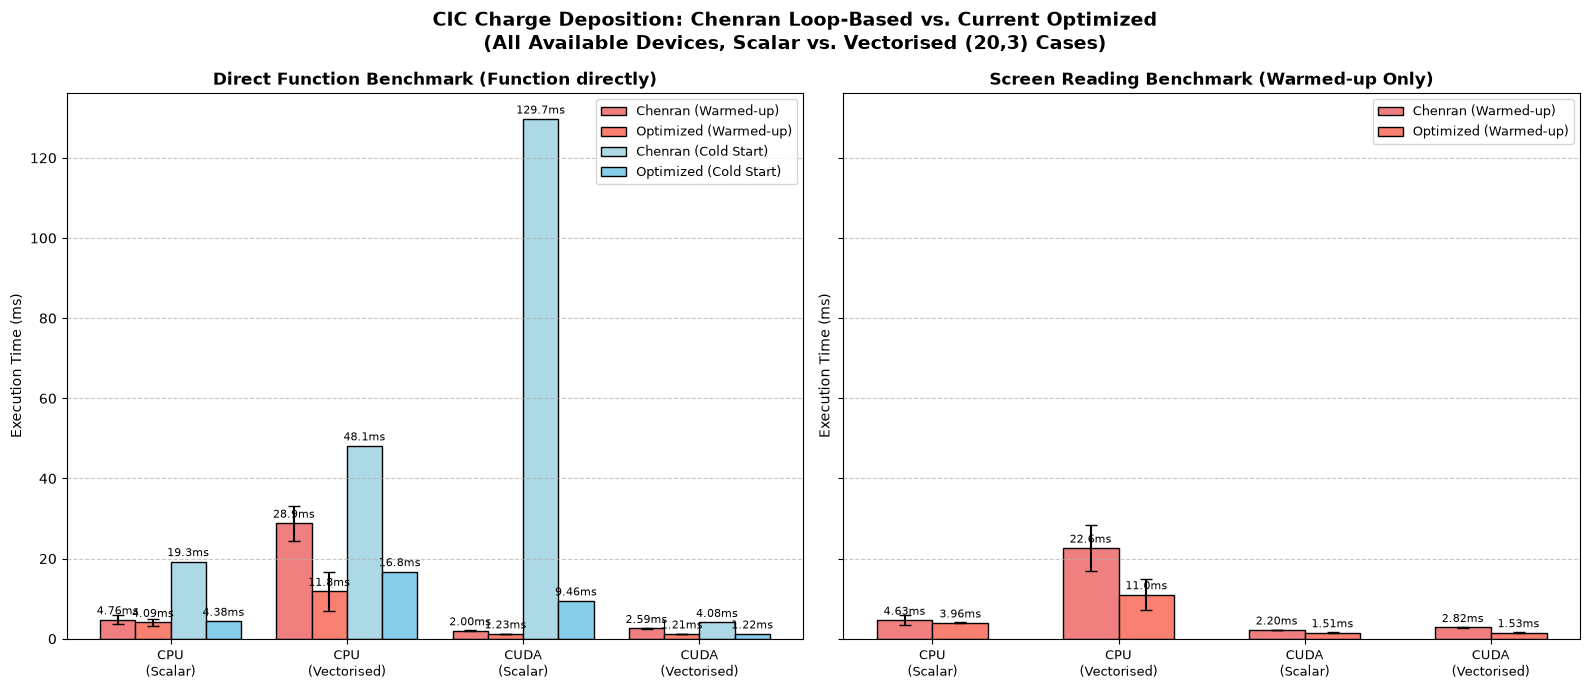

In [5]:
# Generate one final plot with all results in it (subplots for Function and Screen)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 1. Left Subplot: Direct Function Benchmark (includes Cold Start)
ax_func = axes[0]
categories_func = []
warmed_up_means_f = {"Chenran": [], "Optimized": []}
warmed_up_stds_f = {"Chenran": [], "Optimized": []}
cold_starts_f = {"Chenran": [], "Optimized": []}

for dev_name in device_names:
    for case in ["Scalar", "Vectorised"]:
        categories_func.append(f"{dev_name.upper()}\n({case})")
        for impl in ["Chenran", "Optimized"]:
            times_dict = func_results[dev_name][case][impl]
            warmed_up_means_f[impl].append(np.mean(times_dict["warmed_up"]) * 1000)
            warmed_up_stds_f[impl].append(np.std(times_dict["warmed_up"]) * 1000)
            cold_starts_f[impl].append(times_dict["cold_start"] * 1000)

x_func = np.arange(len(categories_func))
width_func = 0.2

rects_w_c_f = ax_func.bar(
    x_func - 1.5 * width_func,
    warmed_up_means_f["Chenran"],
    width_func,
    yerr=warmed_up_stds_f["Chenran"],
    label="Chenran (Warmed-up)",
    capsize=4,
    color="lightcoral",
    edgecolor="black",
)
rects_w_o_f = ax_func.bar(
    x_func - 0.5 * width_func,
    warmed_up_means_f["Optimized"],
    width_func,
    yerr=warmed_up_stds_f["Optimized"],
    label="Optimized (Warmed-up)",
    capsize=4,
    color="salmon",
    edgecolor="black",
)
rects_c_c_f = ax_func.bar(
    x_func + 0.5 * width_func,
    cold_starts_f["Chenran"],
    width_func,
    label="Chenran (Cold Start)",
    color="lightblue",
    edgecolor="black",
)
rects_c_o_f = ax_func.bar(
    x_func + 1.5 * width_func,
    cold_starts_f["Optimized"],
    width_func,
    label="Optimized (Cold Start)",
    color="skyblue",
    edgecolor="black",
)

ax_func.set_ylabel("Execution Time (ms)")
ax_func.set_title(
    "Direct Function Benchmark (Function directly)", fontsize=12, fontweight="bold"
)
ax_func.set_xticks(x_func)
ax_func.set_xticklabels(categories_func, fontsize=9)
ax_func.legend(fontsize=9)
ax_func.grid(axis="y", linestyle="--", alpha=0.7)

# 2. Right Subplot: Screen Reading Benchmark (Warmed-up only)
ax_screen = axes[1]
categories_screen = []
warmed_up_means_s = {"Chenran": [], "Optimized": []}
warmed_up_stds_s = {"Chenran": [], "Optimized": []}

for dev_name in device_names:
    for case in ["Scalar", "Vectorised"]:
        categories_screen.append(f"{dev_name.upper()}\n({case})")
        for impl in ["Chenran", "Optimized"]:
            times_dict = screen_results[dev_name][case][impl]
            warmed_up_means_s[impl].append(np.mean(times_dict["warmed_up"]) * 1000)
            warmed_up_stds_s[impl].append(np.std(times_dict["warmed_up"]) * 1000)

x_screen = np.arange(len(categories_screen))
width_screen = 0.3

rects_w_c_s = ax_screen.bar(
    x_screen - 0.5 * width_screen,
    warmed_up_means_s["Chenran"],
    width_screen,
    yerr=warmed_up_stds_s["Chenran"],
    label="Chenran (Warmed-up)",
    capsize=4,
    color="lightcoral",
    edgecolor="black",
)
rects_w_o_s = ax_screen.bar(
    x_screen + 0.5 * width_screen,
    warmed_up_means_s["Optimized"],
    width_screen,
    yerr=warmed_up_stds_s["Optimized"],
    label="Optimized (Warmed-up)",
    capsize=4,
    color="salmon",
    edgecolor="black",
)

ax_screen.set_ylabel("Execution Time (ms)")
ax_screen.set_title(
    "Screen Reading Benchmark (Warmed-up Only)", fontsize=12, fontweight="bold"
)
ax_screen.set_xticks(x_screen)
ax_screen.set_xticklabels(categories_screen, fontsize=9)
ax_screen.legend(fontsize=9)
ax_screen.grid(axis="y", linestyle="--", alpha=0.7)


# Auto-labels
def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        txt = f"{height:.1f}ms" if height > 10 else f"{height:.2f}ms"
        ax.annotate(
            txt,
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 2),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


autolabel(ax_func, rects_w_c_f)
autolabel(ax_func, rects_w_o_f)
autolabel(ax_func, rects_c_c_f)
autolabel(ax_func, rects_c_o_f)

autolabel(ax_screen, rects_w_c_s)
autolabel(ax_screen, rects_w_o_s)

plt.suptitle(
    "CIC Charge Deposition: Chenran Loop-Based vs. Current Optimized\n(All Available Devices, Scalar vs. Vectorised (20,3) Cases)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()